# DeathQuanta

## DeathQuanta Normalization

In [1]:
import os
import sys
import shutil
import math
import warnings
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import *
from enum import Enum
from scipy.spatial import Voronoi
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import LabelEncoder
from scipy.stats import wasserstein_distance
sys.path.append("/home/esraan/CellDeathSpreading/")
from src.utils import get_experiment_cell_death_times_by_specific_siliding_window,read_experiment_cell_xy_and_death_times
from src.NucleationAndPropagationMeasurements import replace_ugly_long_name
from src.quanta_utils import get_neighbors
from src.DeathQuanta import DeathQuanta

In [2]:
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/all_csv_files_minutes_microns_with_sytox.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
group_data = {}
for idx in range(len(exp_names)):
    # if not all(meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["DeathMode"] == 'Apoptosis'):
    #     continue
    if 'nec' in exp_names[idx] or 'apop' in exp_names[idx] or 'out' in exp_names[idx] or 'skt' in exp_names[idx].lower() or 'puredeath3' in exp_names[idx] or 'field3' in exp_names[idx]:# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
        continue
    # if 'pure' not in exp_names[idx]:# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
    #     continue
    print(exp_names[idx])
    exp_full_path = os.path.join(exps_dir_name, exp_names[idx])
    csv_file = pd.read_csv(exp_full_path)
    dist_threshold = 100 # microns
    cells_location = csv_file[["cell_x","cell_y"]].values
    di_times = csv_file[['death_time']].values
    death_modes = csv_file[["Mode"]].values if "Mode" in csv_file.columns else None
    de_qu = DeathQuanta(cells_xy=cells_location,
                        death_times=di_times, 
                        death_modes=death_modes,
                        dist_threshold=dist_threshold,
                        normalize = True,
                        n_type = 'z_score',
                        filter_neighbors_by_distance=True,
                        neighbors_level=1,
                        pure_type = "necrosis" if "nec" in exp_names[idx] else "apoptosis")
    tod_pairs_1 = de_qu.get_org_deltaTOD_neighbors_pairs()
    group_data[meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["Origin"].values[0]] = tod_pairs_1 # tod_pairs_1.get('apoptosis', []) + tod_pairs_1.get('necrosis', []) if isinstance(tod_pairs_1, dict) else tod_pairs_1

field13_crop-001_ROI#1_annotation_mixed.csv
Field14-002_ROI#1_annotation_mixed.csv
7-20-23_10arednuclei_ROI#10_annotation_mixed.csv
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv
purecolony3_sytox_based.csv
purecolony_sytox_based.csv
purecolony2_sytox_based.csv
mixcolony1.csv
mixcolony2_field13.csv
mixcolony3.csv
3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath1_sytox_based.csv
3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath2_sytox_based.csv


/tmp/ipykernel_2307509/2308513660.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GroupLabel', y='deltaTOD', data=df,


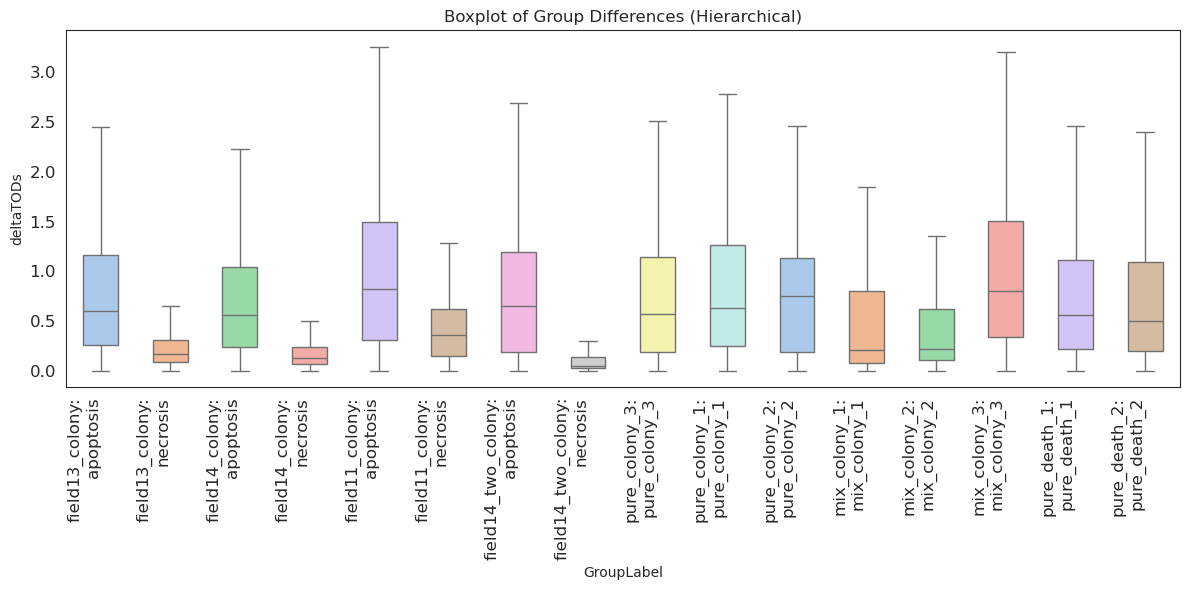

/tmp/ipykernel_2307509/2308513660.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='MainGroup', y='deltaTOD', data=df,


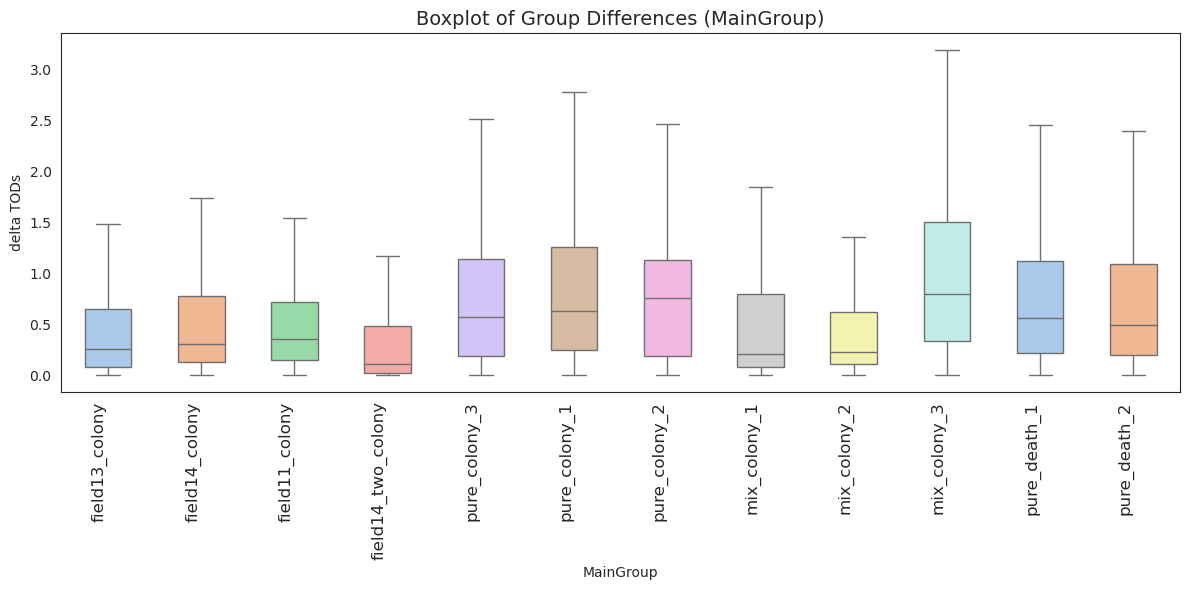

In [3]:
flattened_data = {'Group': [], 'deltaTOD': []}
# Remove "entosis" from group_data
filtered_group_data = {}
for group_name, subgroups in group_data.items():
    if isinstance(subgroups, dict):  # Check if subgroups exist
        filtered_subgroups = {subgroup_name: arrays for subgroup_name, arrays in subgroups.items() if subgroup_name != "entosis"}
        if filtered_subgroups:  # Add only if there are remaining subgroups
            filtered_group_data[group_name] = filtered_subgroups
    else:
        filtered_group_data[group_name] = subgroups  # Keep flat structure unchanged

group_data = filtered_group_data

for group_name, value in group_data.items():
    if isinstance(value, dict):  # Nested: group → subgroup → arrays
        for subgroup_name, arrays in value.items():
            label = f"{group_name}/{subgroup_name}"
            for arr in arrays:
                flattened_data['Group'].extend([label] * len(arr))
                flattened_data['deltaTOD'].extend(arr)
    else:  # Flat list of arrays
        for arr in value:
            flattened_data['Group'].extend([group_name] * len(arr))
            flattened_data['deltaTOD'].extend(arr)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(flattened_data)

# Sort groups hierarchically
df['MainGroup'] = df['Group'].apply(lambda x: x.split('/')[0])
df['SubGroup'] = df['Group'].apply(lambda x: x.split('/')[1] if '/' in x else x)
df['GroupLabel'] = df['MainGroup'] + ':\n' + df['SubGroup']  # for axis formatting

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.set_style("white") 
sns.boxplot(x='GroupLabel', y='deltaTOD', data=df,
            width=0.5, palette='pastel', showfliers=False)

# Annotate quartiles
for i, label in enumerate(df['GroupLabel'].unique()):
    values = df[df['GroupLabel'] == label]['deltaTOD']
    median = np.median(values)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)

    # Annotate: uncomment if needed
    # plt.text(i, median, f'{median:.2f}', va='center', ha='right', fontsize=9, color='black')
    # plt.text(i, q1, f'{q1:.2f}', va='center', ha='right', fontsize=9, color='blue')
    # plt.text(i, q3, f'{q3:.2f}', va='center', ha='right', fontsize=9, color='red')
plt.xticks(fontsize=12, rotation=90, ha='right',ticks=range(len(df['GroupLabel'].unique())))
plt.yticks(fontsize=12)
# Format plot
# plt.xticks(rotation=90, ha='right')
plt.title('Boxplot of Group Differences (Hierarchical)')
plt.ylabel('deltaTODs')
plt.grid(False)#, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_hierarchical.svg", format="svg", dpi=300)
plt.show()
# Save the plot as a high-resolution image suitable for Adobe Illustrator
# Boxplot based on MainGroup
plt.figure(figsize=(12, 6))
sns.set_style("white") 
sns.boxplot(x='MainGroup', y='deltaTOD', data=df,
            width=0.5, palette='pastel', showfliers=False)
plt.title('Boxplot of Group Differences (MainGroup)', fontsize=14)
plt.ylabel('delta TODs')
plt.xlabel('MainGroup')
plt.xticks(fontsize=12, rotation=90, ha='right')
plt.tight_layout()
plt.show()


In [49]:
df['MainGroup'].unique()
filtered_df = df.copy()

In [4]:
# filtered_df = df.copy()
# Filter out groups with "mixed" in their Group or MainGroup
filtered_df = df[~df['Group'].str.contains('pure', case=False) & ~df['MainGroup'].str.contains('field3', case=False ) & ~df['SubGroup'].str.contains('mix', case=False)]

# Display the filtered DataFrame
print(filtered_df)

                            Group  deltaTOD           MainGroup   SubGroup  \
0        field13_colony/apoptosis  1.824764      field13_colony  apoptosis   
1        field13_colony/apoptosis  1.824764      field13_colony  apoptosis   
2        field13_colony/apoptosis  3.792088      field13_colony  apoptosis   
3        field13_colony/apoptosis  3.792088      field13_colony  apoptosis   
4        field13_colony/apoptosis  1.368573      field13_colony  apoptosis   
...                           ...       ...                 ...        ...   
9275  field14_two_colony/necrosis  0.895704  field14_two_colony   necrosis   
9276  field14_two_colony/necrosis  0.379996  field14_two_colony   necrosis   
9277  field14_two_colony/necrosis  0.814277  field14_two_colony   necrosis   
9278  field14_two_colony/necrosis  0.651421  field14_two_colony   necrosis   
9279  field14_two_colony/necrosis  0.488566  field14_two_colony   necrosis   

                         GroupLabel  
0        field13_colony:\

In [44]:
filtered_df = df.copy()
# Filter out groups with "mixed" in their Group or MainGroup
filtered_df = df[~df['Group'].str.contains('nec', case=False) & ~df['MainGroup'].str.contains('field3', case=False ) & ~df['SubGroup'].str.contains('apop', case=False)]

# Display the filtered DataFrame
print(filtered_df)

               Group  deltaTOD      MainGroup       SubGroup  \
9280   pure_colony_3  1.519555  pure_colony_3  pure_colony_3   
9281   pure_colony_3  0.189944  pure_colony_3  pure_colony_3   
9282   pure_colony_3  1.329610  pure_colony_3  pure_colony_3   
9283   pure_colony_3  5.171235  pure_colony_3  pure_colony_3   
9284   pure_colony_3  0.949722  pure_colony_3  pure_colony_3   
...              ...       ...            ...            ...   
40655   pure_death_2  3.077133   pure_death_2   pure_death_2   
40656   pure_death_2  2.378918   pure_death_2   pure_death_2   
40657   pure_death_2  0.084783   pure_death_2   pure_death_2   
40658   pure_death_2  1.082233   pure_death_2   pure_death_2   
40659   pure_death_2  2.877643   pure_death_2   pure_death_2   

                          GroupLabel  
9280   pure_colony_3:\npure_colony_3  
9281   pure_colony_3:\npure_colony_3  
9282   pure_colony_3:\npure_colony_3  
9283   pure_colony_3:\npure_colony_3  
9284   pure_colony_3:\npure_colony_3

In [5]:
from scipy.stats import wasserstein_distance, energy_distance
import numpy as np
import scipy.stats as stats
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
def compute_distance_matrix(filtered_df, method='ks_2samp', column_name='deltaTOD', labels = 'GroupLabel'):
    group_names = filtered_df[labels].unique()
    n = len(group_names)
    dist_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i + 1, n):
            group_i_values = filtered_df[filtered_df[labels] == group_names[i]][column_name].values
            group_j_values = filtered_df[filtered_df[labels] == group_names[j]][column_name].values
            if method == 'wasserstein':
                d = wasserstein_distance(group_i_values, group_j_values)
            elif method == 'energy':
                d = energy_distance(group_i_values, group_j_values)
            elif method == 'ks_2samp':
                d, val = stats.ks_2samp(group_i_values, group_j_values)
                print(f"KS Statistic of {group_names[i]} and {group_names[j]}: {val}")
            dist_matrix[i, j] = dist_matrix[j, i] = d
    return dist_matrix, group_names


KS Statistic of field13_colony:
apoptosis and field13_colony:
necrosis: 1.667362646366745e-126
KS Statistic of field13_colony:
apoptosis and field14_colony:
apoptosis: 0.07668754017959581
KS Statistic of field13_colony:
apoptosis and field14_colony:
necrosis: 5.5030687369808076e-160
KS Statistic of field13_colony:
apoptosis and field11_colony:
apoptosis: 0.0030971066839961766
KS Statistic of field13_colony:
apoptosis and field11_colony:
necrosis: 1.1770960928177753e-27
KS Statistic of field13_colony:
apoptosis and field14_two_colony:
apoptosis: 7.125895961554768e-05
KS Statistic of field13_colony:
apoptosis and field14_two_colony:
necrosis: 1.22e-321
KS Statistic of field13_colony:
necrosis and field14_colony:
apoptosis: 8.293110626227102e-152
KS Statistic of field13_colony:
necrosis and field14_colony:
necrosis: 1.2967777505612082e-09
KS Statistic of field13_colony:
necrosis and field11_colony:
apoptosis: 1.3333679173627281e-31
KS Statistic of field13_colony:
necrosis and field11_colo

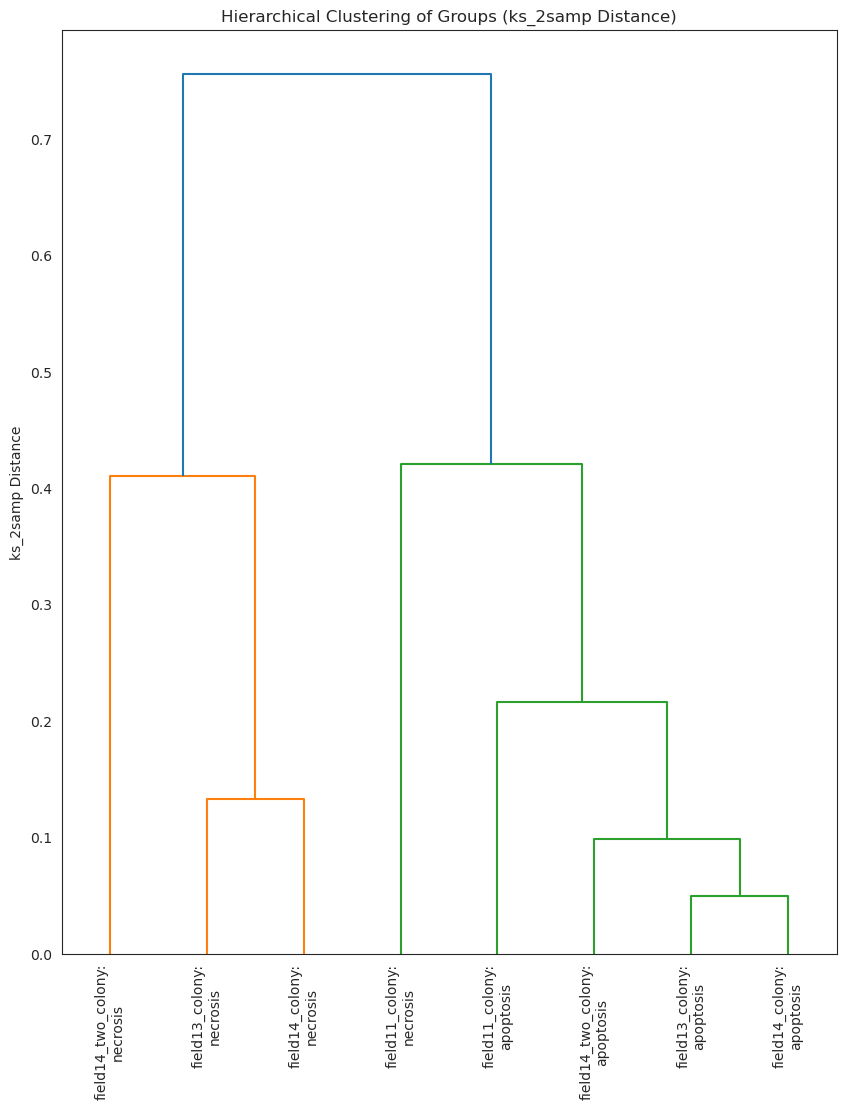

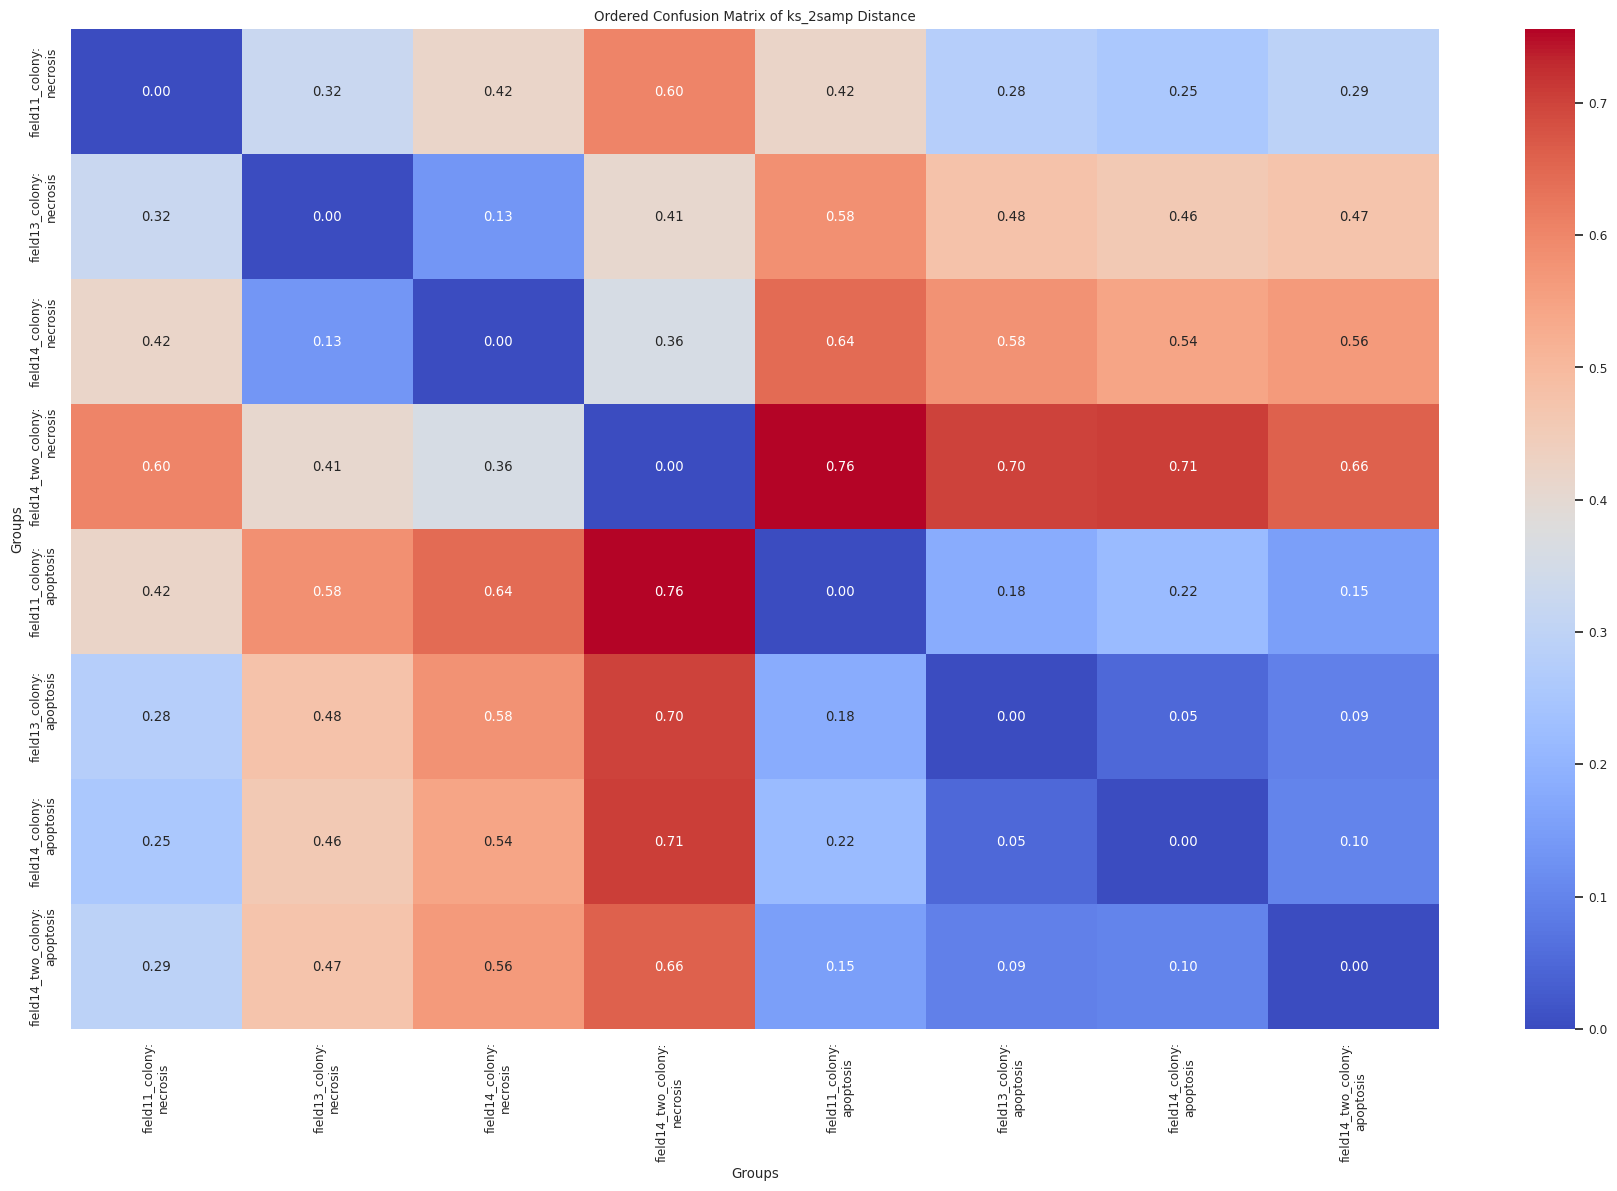

In [6]:
# Compute the energy distance matrix
method_distance = 'ks_2samp'
column = 'deltaTOD'
linkage_method = 'complete'
dist_matrix, group_names = compute_distance_matrix(filtered_df,method=method_distance, column_name=column)#, labels= 'MainGroup')

# Perform hierarchical clustering
linkage_matrix = linkage(squareform(dist_matrix), method=linkage_method, metric = 'euclidean')

# Plot the dendrogram
plt.figure(figsize=(10, 12))
dendrogram(linkage_matrix, labels=group_names, leaf_rotation=90, leaf_font_size=10)
plt.title(f'Hierarchical Clustering of Groups ({method_distance} Distance)')
plt.ylabel(f'{method_distance} Distance')
# plt.tight_layout()
plt.show()

import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

# Convert ks_dist_matrix to a DataFrame
dist_df = pd.DataFrame(dist_matrix, index=group_names, columns=group_names)

# Order the group names: "nec" first, then "apop"
# ordered_group_names = sorted(group_names, key=lambda x: ("pure" not in x.lower(), "field" not in x.lower(), "mix" not in x.lower(), x.lower()))
ordered_group_names = sorted(group_names, key=lambda x: ("nec" not in x.lower(), "apop" not in x.lower(), x.lower()))
dist_df = dist_df.loc[ordered_group_names, ordered_group_names]

# Plot the confusion matrix
plt.figure(figsize=(18,12))
sns.set(font_scale=0.8)
sns.heatmap(dist_df, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=ordered_group_names, yticklabels=ordered_group_names)

# Format the plot
plt.title(f"Ordered Confusion Matrix of {method_distance} Distance")
plt.xlabel("Groups")
plt.ylabel("Groups")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()